In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.datasets import load_iris

In [3]:
iris = load_iris()
print(f"{iris.keys()}")

dict_keys(['data', 'target', 'frame', 'target_names', 'DESCR', 'feature_names', 'filename', 'data_module'])


In [4]:
print(f"{iris.feature_names}")

['sepal length (cm)', 'sepal width (cm)', 'petal length (cm)', 'petal width (cm)']


In [5]:
print(f"{iris.target_names}")

['setosa' 'versicolor' 'virginica']


In [6]:
print(f"{iris.DESCR}")

.. _iris_dataset:

Iris plants dataset
--------------------

**Data Set Characteristics:**

:Number of Instances: 150 (50 in each of three classes)
:Number of Attributes: 4 numeric, predictive attributes and the class
:Attribute Information:
    - sepal length in cm
    - sepal width in cm
    - petal length in cm
    - petal width in cm
    - class:
            - Iris-Setosa
            - Iris-Versicolour
            - Iris-Virginica

:Summary Statistics:

============== ==== ==== ======= ===== ====================
                Min  Max   Mean    SD   Class Correlation
============== ==== ==== ======= ===== ====================
sepal length:   4.3  7.9   5.84   0.83    0.7826
sepal width:    2.0  4.4   3.05   0.43   -0.4194
petal length:   1.0  6.9   3.76   1.76    0.9490  (high!)
petal width:    0.1  2.5   1.20   0.76    0.9565  (high!)
============== ==== ==== ======= ===== ====================

:Missing Attribute Values: None
:Class Distribution: 33.3% for each of 3 classes.
:Cr

In [16]:
iris_df = pd.DataFrame(iris.data, columns = iris.feature_names)
iris_df

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm)
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2
...,...,...,...,...
145,6.7,3.0,5.2,2.3
146,6.3,2.5,5.0,1.9
147,6.5,3.0,5.2,2.0
148,6.2,3.4,5.4,2.3


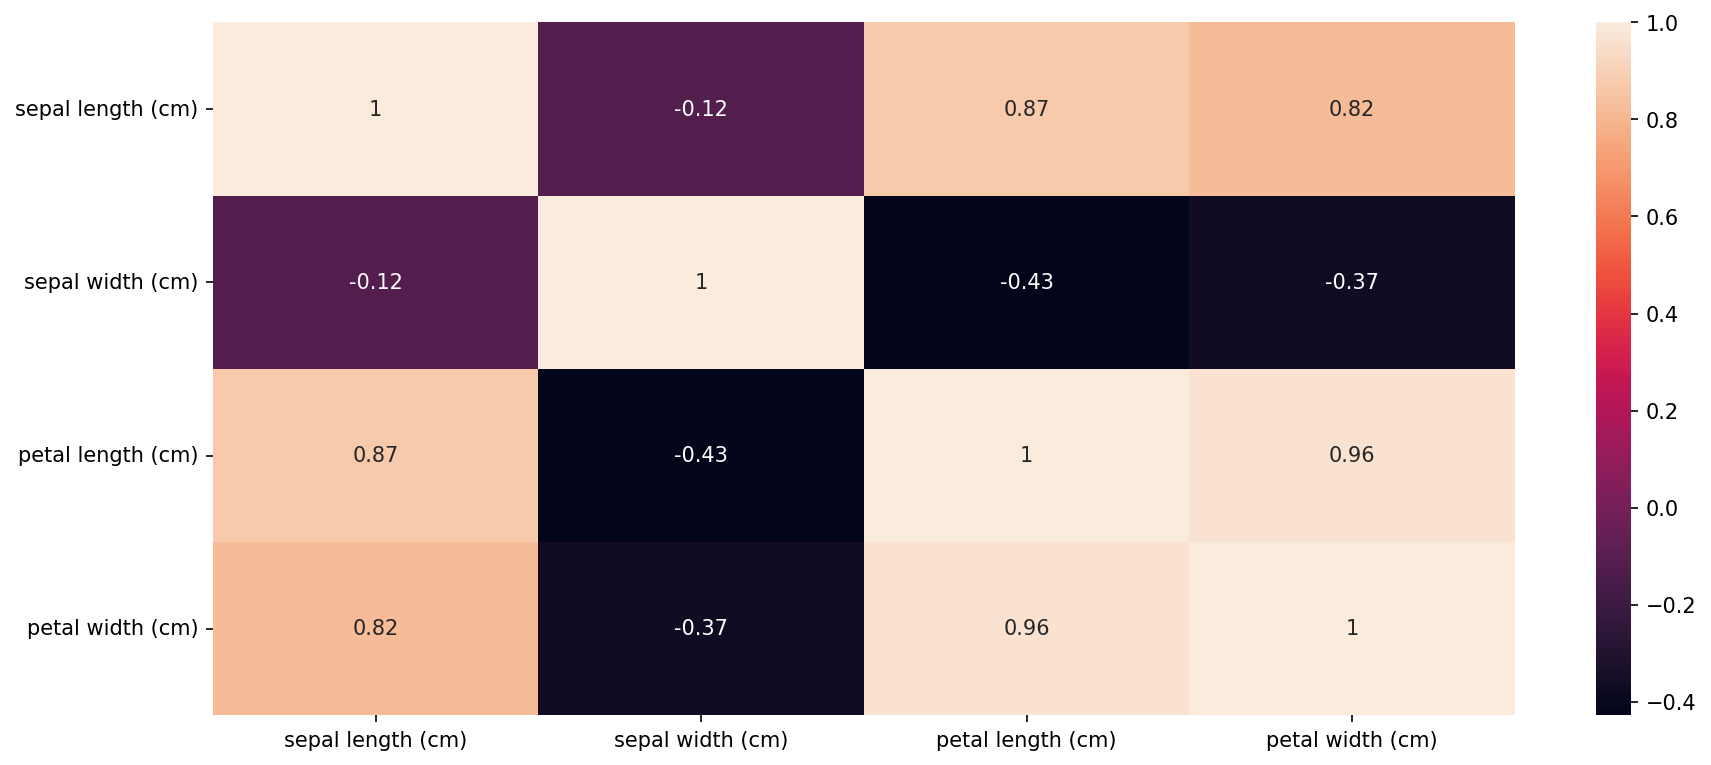

In [8]:
# correlation heatmap over the features
fig, ax = plt.subplots(1, figsize = (14,6), dpi=150)

sns.heatmap(iris_df.corr(), annot=True, ax=ax);


do a correlation heatmap aswell with the targets

In [9]:
# first check the shape, if the rows are equal we can do a check on target
iris.target.shape, iris.data.shape

((150,), (150, 4))

In [ ]:
iris_df_t = pd.DataFrame(iris.target, columns = ["class"])

iris_df_target = pd.concat([iris_df, pd.DataFrame(iris.target, columns = ["class"])], axis = 1)
# https://scikit-learn.org/stable/auto_examples/decomposition/plot_pca_iris.html
# replace numeric targets (0,1,2) with their species names 
iris_df_target["class"] = iris.target_names[iris.target]

iris_df_target.head()


SyntaxError: invalid syntax. Maybe you meant '==' or ':=' instead of '='? (3994863284.py, line 3)

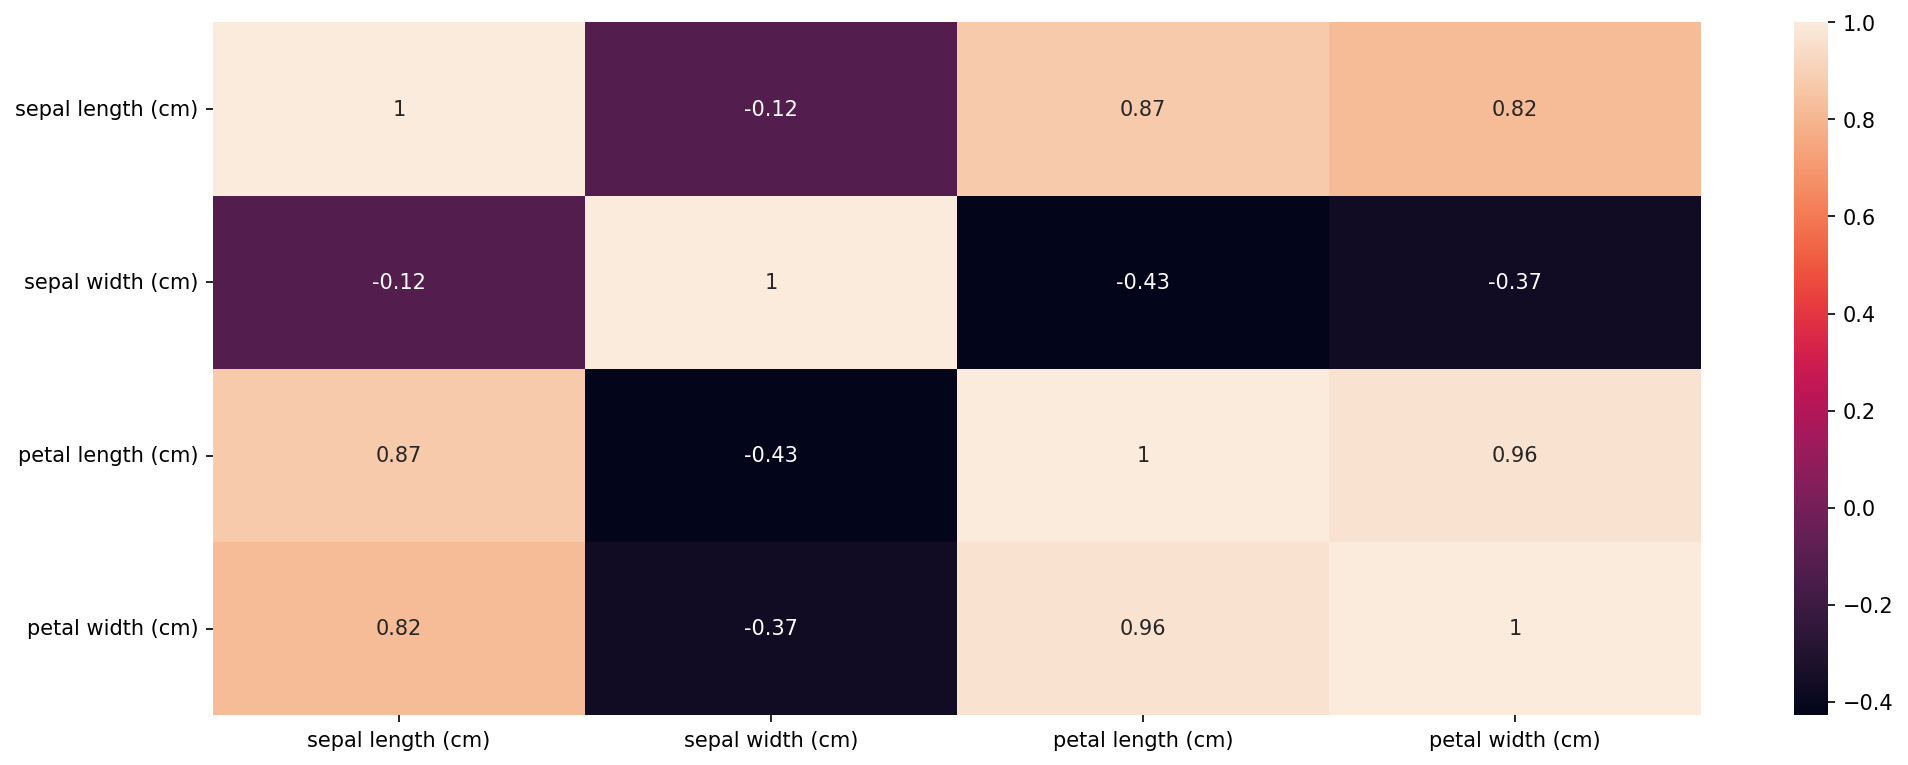

In [11]:
# correlation heatmap over the features and targets
fig, ax = plt.subplots(1, figsize = (16,6), dpi=150)

sns.heatmap(iris_df.corr(), annot=True);

<Axes: >

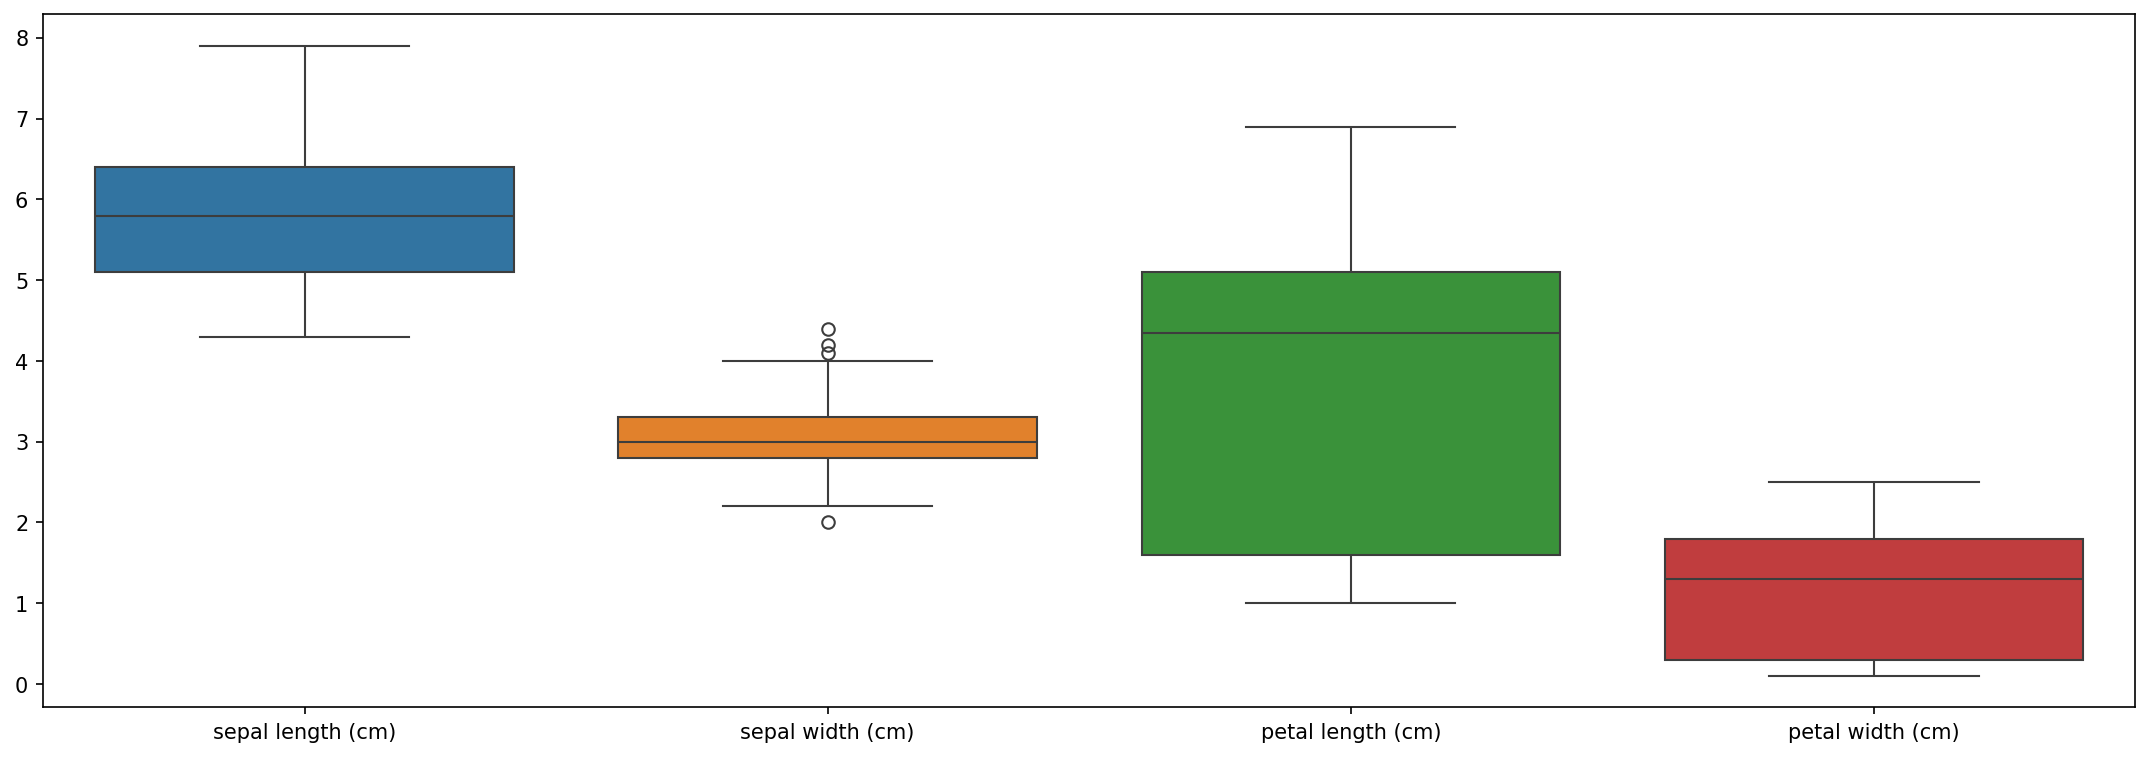

In [32]:
# a boxplot for two features
fig, ax = plt.subplots(1, figsize = (18,6), dpi=150)
sns.boxplot(data = iris_df)

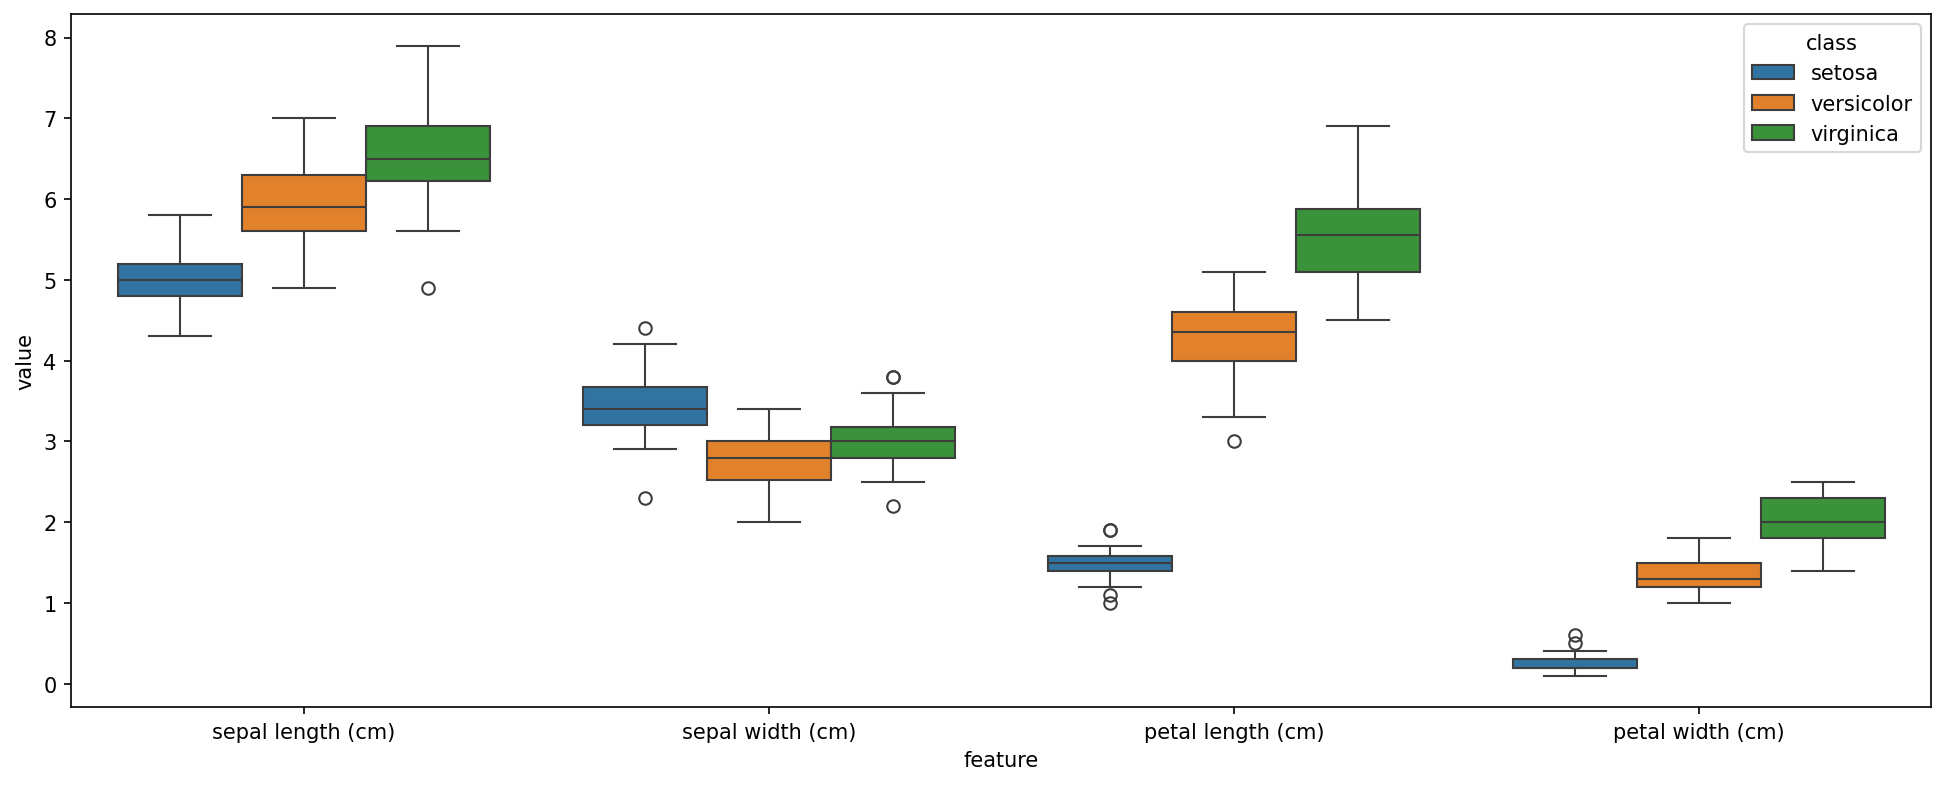

In [13]:
# a boxplot with the features and targets, melt 
iris_long = iris_df_target.melt(id_vars="class",
                         value_vars=iris.feature_names,
                         var_name="feature",
                         value_name="value")

fig, ax = plt.subplots(1, figsize = (16,6), dpi=150)
sns.boxplot(data=iris_long, x="feature", y="value", hue="class");

https://www.geeksforgeeks.org/machine-learning/interquartile-range-to-detect-outliers-in-data/

In [14]:
#1 sort the data in ascending order
iris_sort = iris_df["sepal width (cm)"].values
x = np.sort(iris_sort)
#2 calculate Q1, Q3 and IQR
Q1 = np.percentile(x, 25, interpolation= 'midpoint')
Q3 = np.percentile(x, 75, interpolation = 'midpoint')

IQR = Q3 - Q1

#3 find the lower and upper limits
low_limit = Q1 - 1.5 * IQR
upp_limit = Q3 + 1.5 * IQR

#4 identify the outliers and put them in a list
outlier = []
for x in iris_sort:
    if ((x > upp_limit) or (x < low_limit)):
        outlier.append(x)

print(outlier)

[np.float64(4.4), np.float64(4.1), np.float64(4.2), np.float64(2.0)]


for multiple columns
https://www.youtube.com/watch?v=Vc4cXIAa69Y

In [15]:

for col in iris_df.columns:
    print(f"\n{col}:")
    for cls, grp in iris_df_target.groupby("class"):
        x = np.sort(grp[col].values)
        Q1 = np.percentile(x, 25, method="midpoint")
        Q3 = np.percentile(x, 75, method="midpoint")
        IQR = Q3 - Q1
        low, upp = Q1 - 1.5*IQR, Q3 + 1.5*IQR
        outliers = x[(x < low) | (x > upp)]
        print(f"  {cls}: {len(outliers)} -> {outliers[:10]}")



sepal length (cm):
  setosa: 0 -> []
  versicolor: 0 -> []
  virginica: 2 -> [4.9 7.9]

sepal width (cm):
  setosa: 2 -> [2.3 4.4]
  versicolor: 0 -> []
  virginica: 3 -> [2.2 3.8 3.8]

petal length (cm):
  setosa: 4 -> [1.  1.1 1.9 1.9]
  versicolor: 1 -> [3.]
  virginica: 0 -> []

petal width (cm):
  setosa: 2 -> [0.5 0.6]
  versicolor: 0 -> []
  virginica: 0 -> []
